In [22]:
# Import Libraries and modules

# libraries that are used for analysis and visualization

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [23]:
# Impoting data preprocessing libraries
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [24]:
# Importing model selection libraries.
from sklearn.model_selection import train_test_split


In [25]:
# Importing metrics for model evaluation.
from sklearn.metrics import confusion_matrix, accuracy_score

In [26]:
# Importing machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

load the CARDIOVASCULAR RISK DATA

In [27]:
#Dataset First View
risk_df=pd.read_csv('cardiovascular_risk_data.csv',na_values=["NA", "N/A", "null", "None", "?", "-"])

# Viewing the top 5 rows to take a glimpse of the data
risk_df.head(5)

,id,age,education,sex,is_smoking,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,0,64,2.0,F,YES,3.0,0.0,0,0,0,221.0,148.0,85.0,NaN,90.0,80.0,1
1,1,36,4.0,M,NO,0.0,0.0,0,1,0,212.0,168.0,98.0,29.77,72.0,75.0,0
2,2,46,1.0,F,YES,10.0,0.0,0,0,0,250.0,116.0,71.0,20.35,88.0,94.0,0
3,3,50,1.0,M,YES,20.0,0.0,0,1,0,233.0,158.0,88.0,28.26,68.0,94.0,1
4,4,64,1.0,F,YES,30.0,0.0,0,0,0,241.0,136.5,85.0,26.42,70.0,77.0,0


In [28]:
# Viewing the last 5 rows
risk_df.tail(5)

,id,age,education,sex,is_smoking,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
3385,3385,60,1.0,F,NO,0.0,0.0,0,0,0,261.0,123.5,79.0,29.28,70.0,103.0,0
3386,3386,46,1.0,F,NO,0.0,0.0,0,0,0,199.0,102.0,56.0,21.96,80.0,84.0,0
3387,3387,44,3.0,M,YES,3.0,0.0,0,1,0,352.0,164.0,119.0,28.92,73.0,72.0,1
3388,3388,60,1.0,M,NO,0.0,NaN,0,1,0,191.0,167.0,105.0,23.01,80.0,85.0,0
3389,3389,54,3.0,F,NO,0.0,0.0,0,0,0,288.0,124.0,77.0,29.88,79.0,92.0,0


In [29]:
# Dataset Rows & Columns 
risk_df.shape

(3390, 17)

In [30]:
print(f'number of rows : {risk_df.shape[0]}  \nnumber of columns : {risk_df.shape[1]}')

number of rows : 3390  
number of columns : 17


### Dataset Information

In [31]:
risk_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3390 entries, 0 to 3389
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               3390 non-null   int64  
 1   age              3390 non-null   int64  
 2   education        3303 non-null   float64
 3   sex              3390 non-null   str    
 4   is_smoking       3390 non-null   str    
 5   cigsPerDay       3368 non-null   float64
 6   BPMeds           3346 non-null   float64
 7   prevalentStroke  3390 non-null   int64  
 8   prevalentHyp     3390 non-null   int64  
 9   diabetes         3390 non-null   int64  
 10  totChol          3352 non-null   float64
 11  sysBP            3390 non-null   float64
 12  diaBP            3390 non-null   float64
 13  BMI              3376 non-null   float64
 14  heartRate        3389 non-null   float64
 15  glucose          3086 non-null   float64
 16  TenYearCHD       3390 non-null   int64  
dtypes: float64(9), int64(6), 

## Duplicate Values

### How important is it to get rid of duplicate records in my data?

The mere presence of repeated data in the dataset is referred to as "duplication." This could be caused by incorrect data entry or procedures for collecting data. We can save time and money by not sending the same data to the machine learning model multiple times by removing duplicate data from our set.

In [32]:
# Checking Duplicate Values
risk_df.duplicated().sum()

np.int64(0)

Insight: We found that there were no duplicate entries in the above data.

## Missing Values/Null Values

### Why dealing with missing values is necessary?
There are frequently a lot of missing values in the actual data. Corrupted or missing data may result in missing values. Since many machine-learning algorithms do not support missing values, missing data must be handled during the dataset's pre-processing. Therefore, we begin by looking for values that are missing.

In [33]:
# Missing Values/Null Values Count
risk_df.isnull().sum()

id                   0
age                  0
education           87
sex                  0
is_smoking           0
cigsPerDay          22
BPMeds              44
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             38
sysBP                0
diaBP                0
BMI                 14
heartRate            1
glucose            304
TenYearCHD           0
dtype: int64

Insight: We can see there are null values present in totChol, BMI, glucose, BPMeds, cigsPerDay, education has some null values and heartRate has 1 null value.

In [34]:
# Missing Values Percentage
round(risk_df.isnull().sum()/len(risk_df)*100,2)

id                 0.00
age                0.00
education          2.57
sex                0.00
is_smoking         0.00
cigsPerDay         0.65
BPMeds             1.30
prevalentStroke    0.00
prevalentHyp       0.00
diabetes           0.00
totChol            1.12
sysBP              0.00
diaBP              0.00
BMI                0.41
heartRate          0.03
glucose            8.97
TenYearCHD         0.00
dtype: float64

### Insight: glucose column has significant number of missing values

<Axes: >

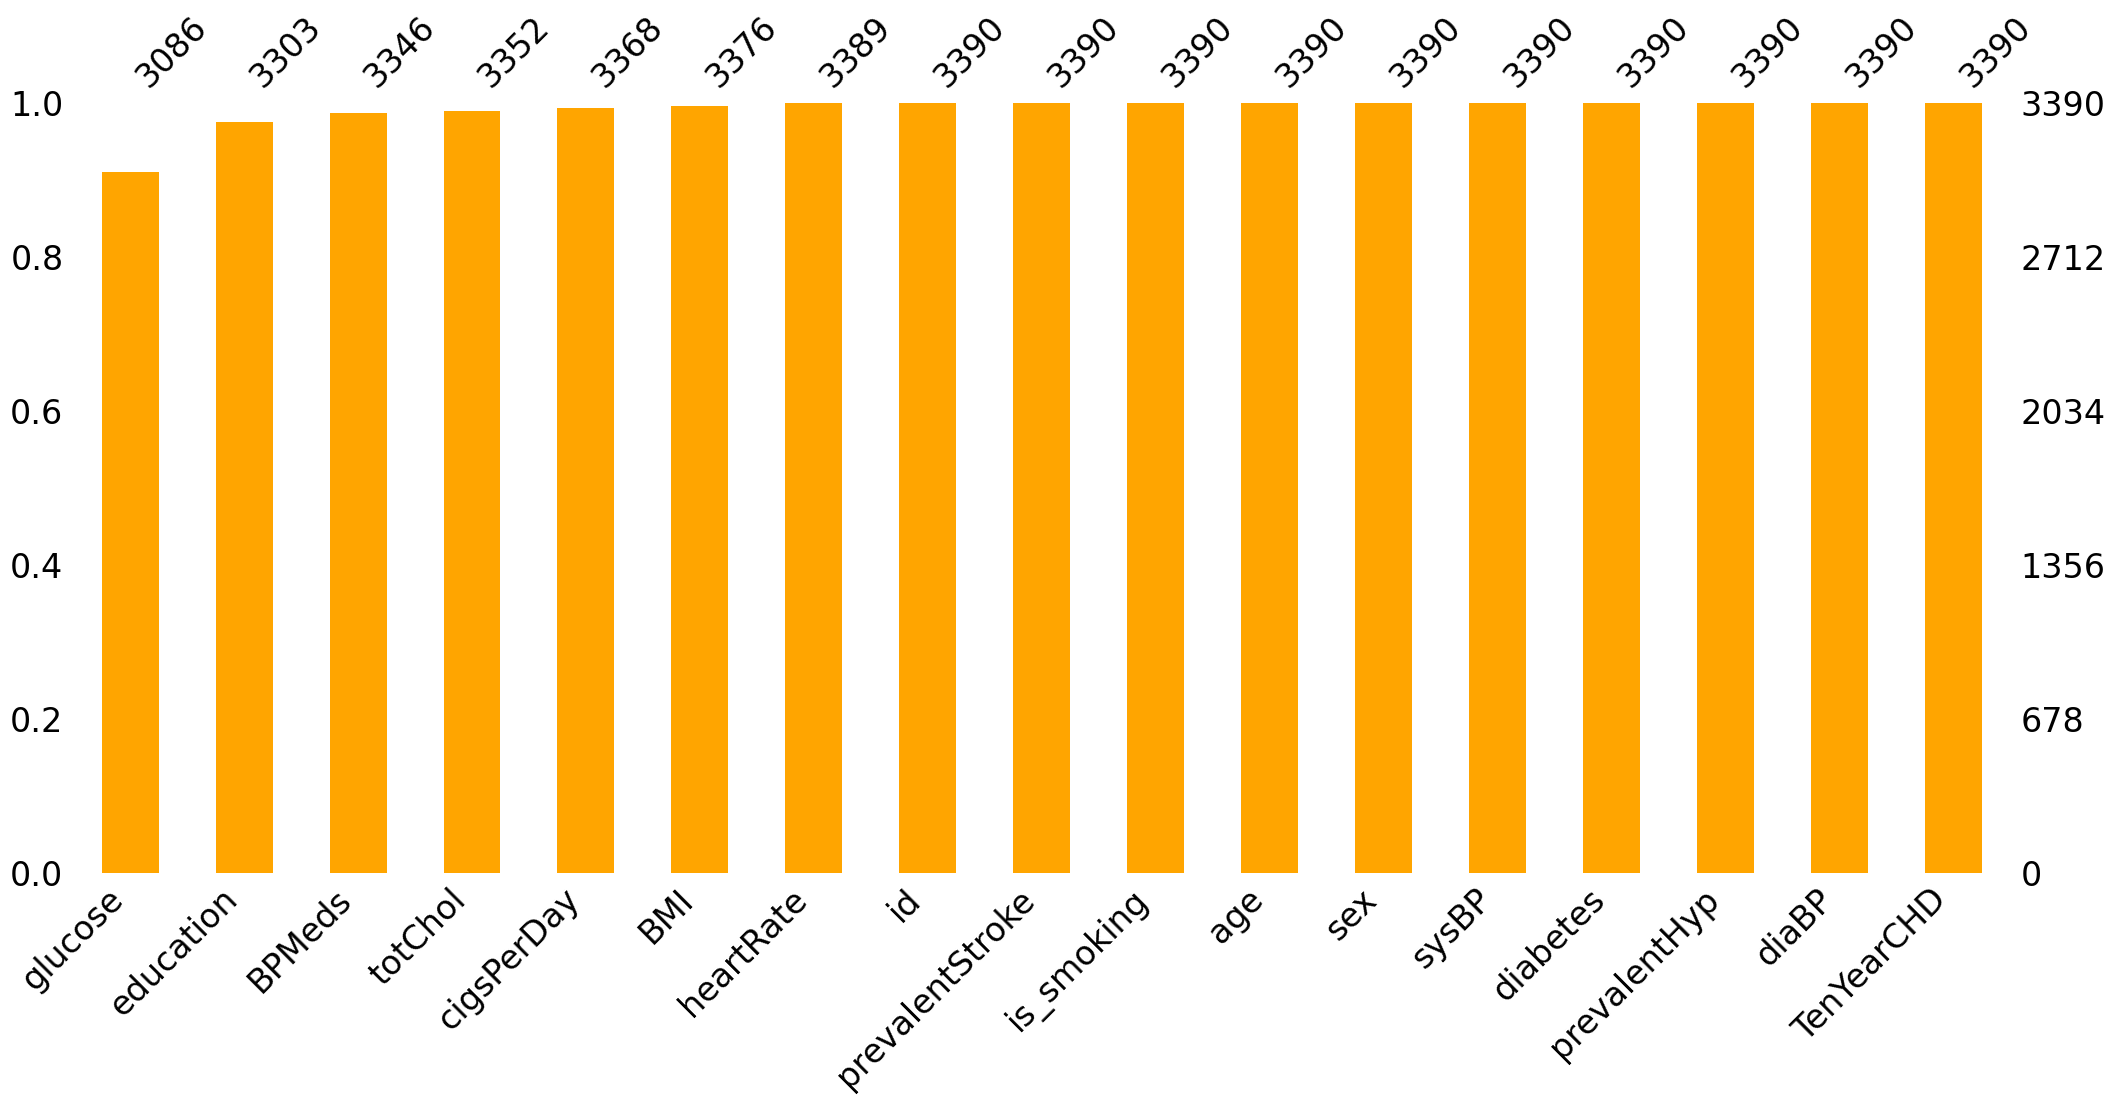

In [35]:
# Visualizing the missing values
import missingno as msno
msno.bar(risk_df,color='orange',sort='ascending',fontsize=24)

<Axes: >

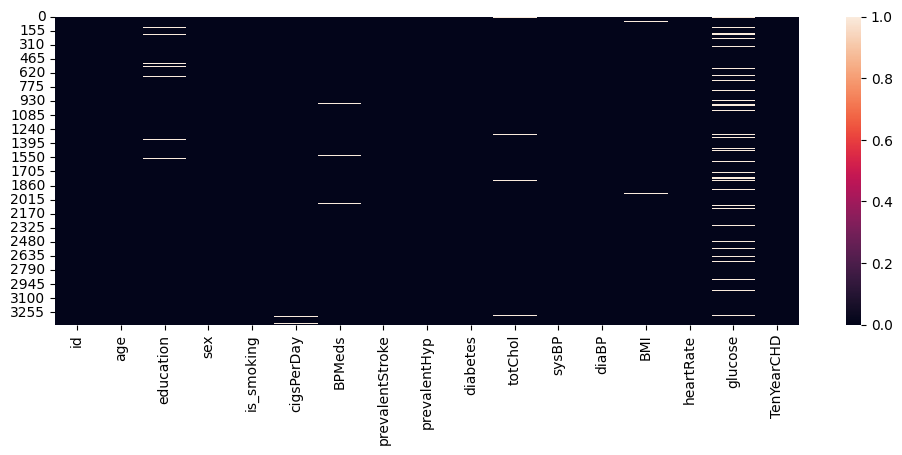

In [36]:
# Visualizing the missing values using Heatmap
plt.figure(figsize=(12,4))
sns.heatmap(risk_df.isna())

### Insight: There is no relation between any columns for missingness
if there would be same pattern for white lines in heatmap then it means two columns missingness have same relation, also if white lines are clustered in some part of a column then we say it is not MCAR but MAR or MNAR and data may be time-ordered or rows represents specific subgroups or dataset made by merging data

## What did you know about your dataset?

The data comes from an ongoing cardiovascular study of Framingham, Massachusetts, residents. The purpose of the classification is to determine whether the patient is at risk for coronary heart disease (CHD) in the ten years to come. The data about the patients is provided by the dataset. It incorporates more than 4,000 records and 15 ascribes.
 
 A classification algorithm is a method of supervised learning that divides data into various classes by utilizing data training. Data or observations are used to train classification predictive modeling, and new observations are categorized into classes or groups.
 
 There are 3390 rows and 16 columns in the dataset. In the 'education', 'cigsPerDay', 'BPMeds', 'totChol', 'BMI', 'heartRate', and 'glucose', there are missing values. The dataset does not contain any duplicate values.
 
 A potential risk factor exists for each attribute. Demographic, behavioral, and medical risk factors are these characteristics.

 First, we should try to understand the dataset through EDA, and then we can deal with null values later.

In [37]:
#Understanding Your Variables
risk_df.columns

Index(['id', 'age', 'education', 'sex', 'is_smoking', 'cigsPerDay', 'BPMeds',
       'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP',
       'diaBP', 'BMI', 'heartRate', 'glucose', 'TenYearCHD'],
      dtype='str')

###  Statistical Summary

In [38]:
# Dataset Describe    (used to get statistics of numerical columns)
risk_df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,3390.0,1694.500000,978.753033,0.00,847.25,1694.50,2541.75,3389.0
age,3390.0,49.542183,8.592878,32.00,42.00,49.00,56.00,70.0
education,3303.0,1.970936,1.019081,1.00,1.00,2.00,3.00,4.0
cigsPerDay,3368.0,9.069477,11.879078,0.00,0.00,0.00,20.00,70.0
BPMeds,3346.0,0.029886,0.170299,0.00,0.00,0.00,0.00,1.0
prevalentStroke,3390.0,0.006490,0.080309,0.00,0.00,0.00,0.00,1.0
prevalentHyp,3390.0,0.315339,0.464719,0.00,0.00,0.00,1.00,1.0
diabetes,3390.0,0.025664,0.158153,0.00,0.00,0.00,0.00,1.0
totChol,3352.0,237.074284,45.247430,107.00,206.00,234.00,264.00,696.0
sysBP,3390.0,132.601180,22.292030,83.50,117.00,128.50,144.00,295.0


## How to analyze
### diaBP feature
mean=82.8, median=82 approx equal hence not skewed, the distribution is usually symmetric

Compare Quartile Distances
median-Q1=82-74=8
Q3-median=90-82=8 
hence distribution is very symmetric.

Detecting Outliers (Using IQR Rule)
IQR=Q3−Q1=90-74=16
Q1−1.5×IQR=74-1.5(16)=50
Q3+1.5×IQR=90+1.5(16)=114

min=48, max=142 hence outliers exist

Most values fall between mean-std , mean+std

 As can be seen in the statistical summary, there is skewness and outliers present in the continuous features 'cigsperday', 'totchol', 'sysbp', 'diebp', 'BMI', 'heartrate', and 'glucose' because there is such a large difference between the 75% percentile value and the maximum value.

In [39]:
#  Variables Description

**Demographic**

*age  : Age of the patient (Continuous - Although the recorded ages have been truncated to whole numbers, the concept of age is continuous)

education : level of education from 1 to 4 (Ordinal Variable)

sex : male or female ("M" or "F")*




**Behavioral**

*is_smoking : whether or not the patient is a current smoker ("YES" or "NO")

cigsPerDay : the number of cigarettes that the person smoked on average in one day (can be considered continuous as one can have any number of cigarettes, even half a cigarette.)
*



**Medical( history)**

*BPMeds : whether or not the patient was on blood pressure medication (Nominal)

prevalentStroke : whether or not the patient had previously had a stroke (Nominal)

prevalentHyp :whether or not the patient was hypertensive (Nominal)

diabetes : whether or not the patient had diabetes (Nominal)*



**Medical(current)**

*totChol :total cholesterol level (Continuous)

sysBP : systolic blood pressure (Continuous)

diaBP : diastolic blood pressure (Continuous)

BMI : Body Mass Index (Continuous)

heartRate : heart rate (Continuous - In medical research, variables such as heart rate though in fact 
discrete, yet are considered continuous because of large number of possible values.)

glucose : glucose level (Continuous)*



**Predict variable (desired target)**

TenYearCHD :(binary: “1”, means “Yes”, “0” means “No”)**

In [40]:
#Check Unique Values for each variable.
# this helps in Detect Data Errors, Remove useless columns, Decide encoding strategy

for i in risk_df.columns:
  print("No. of unique values in",i,"is",risk_df[i].nunique())

No. of unique values in id is 3390
No. of unique values in age is 39
No. of unique values in education is 4
No. of unique values in sex is 2
No. of unique values in is_smoking is 2
No. of unique values in cigsPerDay is 32
No. of unique values in BPMeds is 2
No. of unique values in prevalentStroke is 2
No. of unique values in prevalentHyp is 2
No. of unique values in diabetes is 2
No. of unique values in totChol is 240
No. of unique values in sysBP is 226
No. of unique values in diaBP is 142
No. of unique values in BMI is 1259
No. of unique values in heartRate is 68
No. of unique values in glucose is 132
No. of unique values in TenYearCHD is 2


## Numeric and Categorical features

In [41]:
numeric_features = []
categorical_features = []

''' splitting features into numeric and categoric. '''

'''
If feature has more than 10 categories we will consider it
as numerical_features, remaining features will be added to categorical_features.
'''

for col in risk_df.columns:
    if risk_df[col].nunique()>10:
        numeric_features.append(col)
    else:
        categorical_features.append(col)

print(f'numeric feature : {numeric_features}')
print(f'category feature : {categorical_features}')

numeric feature : ['id', 'age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']
category feature : ['education', 'sex', 'is_smoking', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'TenYearCHD']


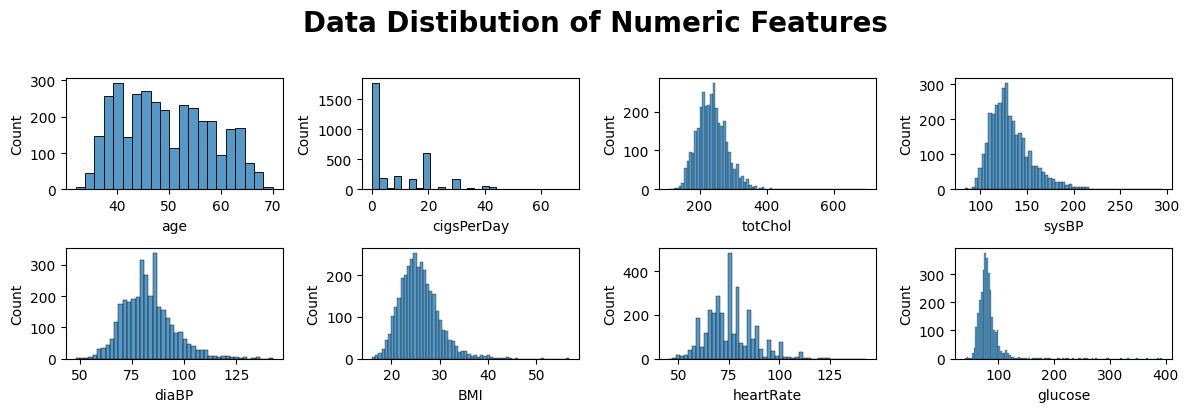

In [42]:
'''Data Distribution of Numeric features'''

plt.figure(figsize=(12,4))

plt.suptitle('Data Distibution of Numeric Features', fontsize=20, fontweight='bold', y=1.02)

for i,col in enumerate(numeric_features[1:]):

  plt.subplot(2, 4, i+1)                       # subplots 2 rows, 4 columns

  # kde plots
  sns.histplot(risk_df[col])  
  # x-axis label
  plt.xlabel(col)
  plt.tight_layout()

Insight from histogram=> cigsPerDay: Many values are 0, meaning many participants do not smoke,smaller groups smoke 20 cigarettes per day,The histogram is highly right-skewed.

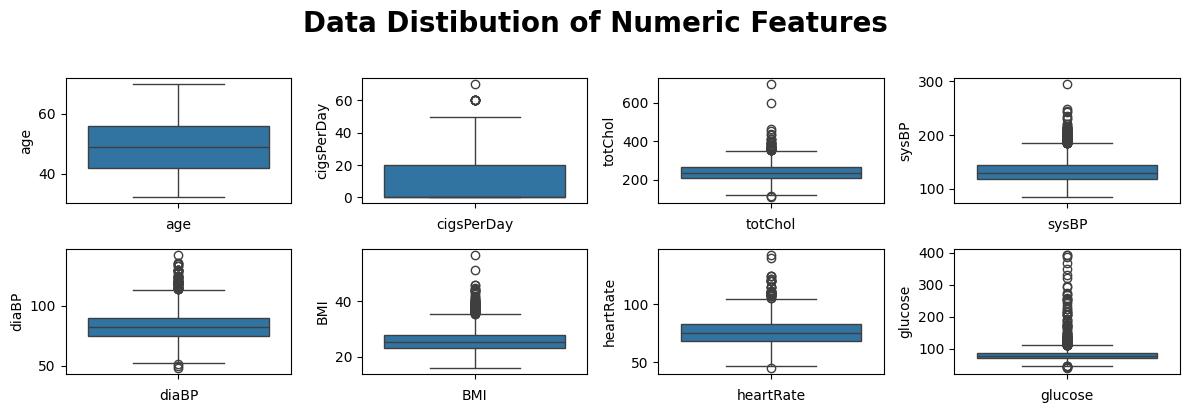

In [43]:
plt.figure(figsize=(12,4))

plt.suptitle('Data Distibution of Numeric Features', fontsize=20, fontweight='bold', y=1.02)

for i,col in enumerate(numeric_features[1:]):

  plt.subplot(2, 4, i+1)                       # subplots 2 rows, 4 columns

  # kde plots
  sns.boxplot(risk_df[col])  
  # x-axis label
  plt.xlabel(col)
  plt.tight_layout()

### Analysis

The boxplot of BMI,sysBP shows several outliers above the upper whisker.

The boxplot of diaBP,heartRate,glucose shows several outliers above the upper whisker and many below the lower whisker.

cigsPerDay shows few outliers above the upper whisker.

glucose,cigsPerDay are highly right skewed as for cigsPerDay 75 percent people cigsPerDay count is less than 20 and for glucose 75 percent people glucose value is less than 87.

sysBP,totChol are right skewed.

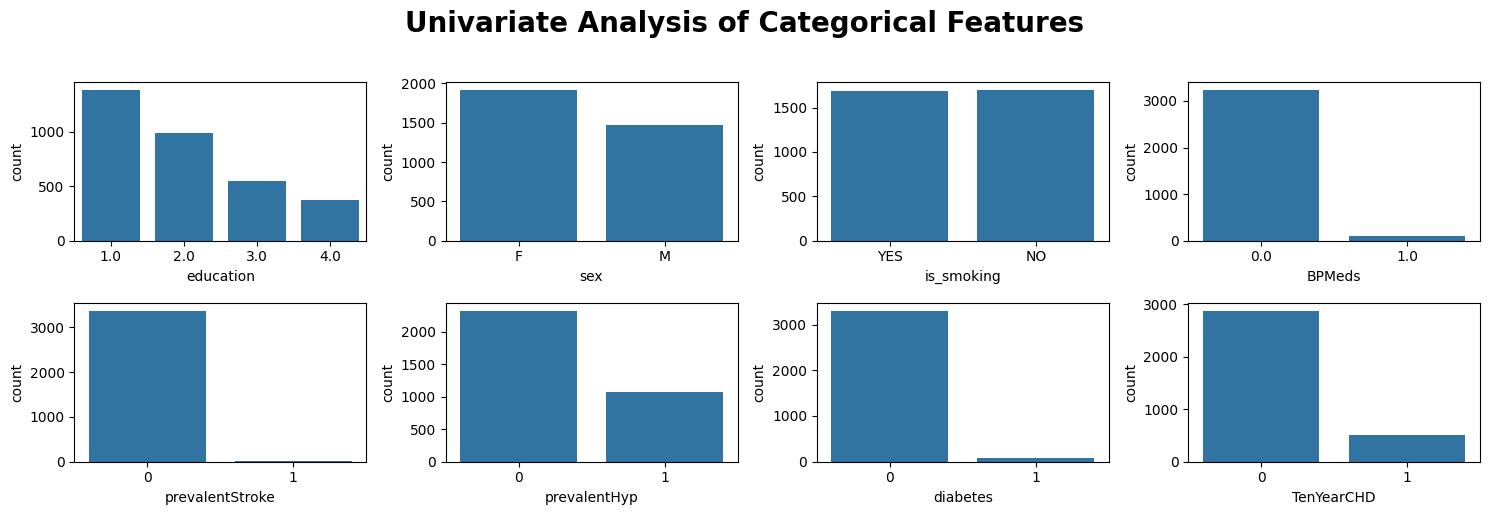

In [44]:
# figsize
plt.figure(figsize=(15,5))
# title
plt.suptitle('Univariate Analysis of Categorical Features', fontsize=20, fontweight='bold', y=1.02)

for i,col in enumerate(categorical_features):
  plt.subplot(2, 4, i+1)            # subplot of 2 rows and 4 columns

  # countplot
  sns.countplot(x=risk_df[col])
  # x-axis label
  plt.xlabel(col)
  plt.tight_layout()

The countplot for TenYearCHD is severely skewed. Roughly 85% of participants do not develop CHD hence model might achieve high "accuracy" simply by predicting everyone is healthy

### plotting graph to analyze age with respect to heartrate which are having Disease or No Disease

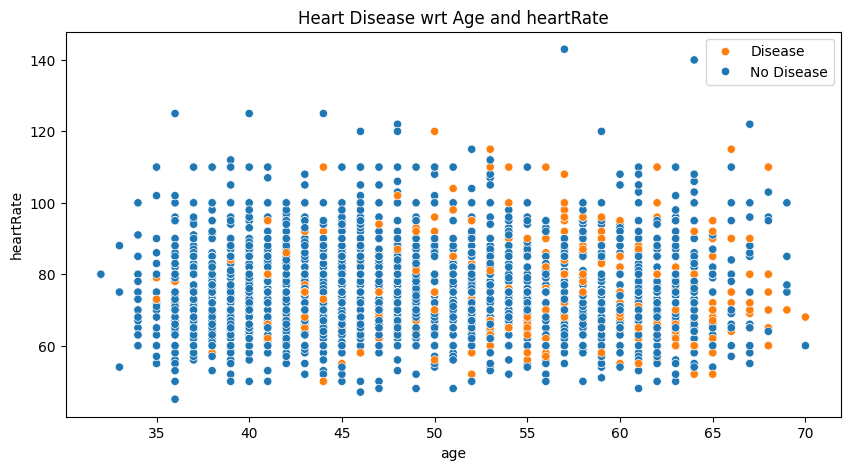

In [45]:
# figsize
plt.figure(figsize=(10,5))
# scatterplot
sns.scatterplot(x=risk_df['age'], y=risk_df['heartRate'], hue=risk_df['TenYearCHD'])
# title
plt.title('Heart Disease wrt Age and heartRate')
plt.legend(['Disease', 'No Disease'])

### Insight: younger ages.	It is rare to see CHD cases in participants under 35 in this dataset, even with high heart rates.

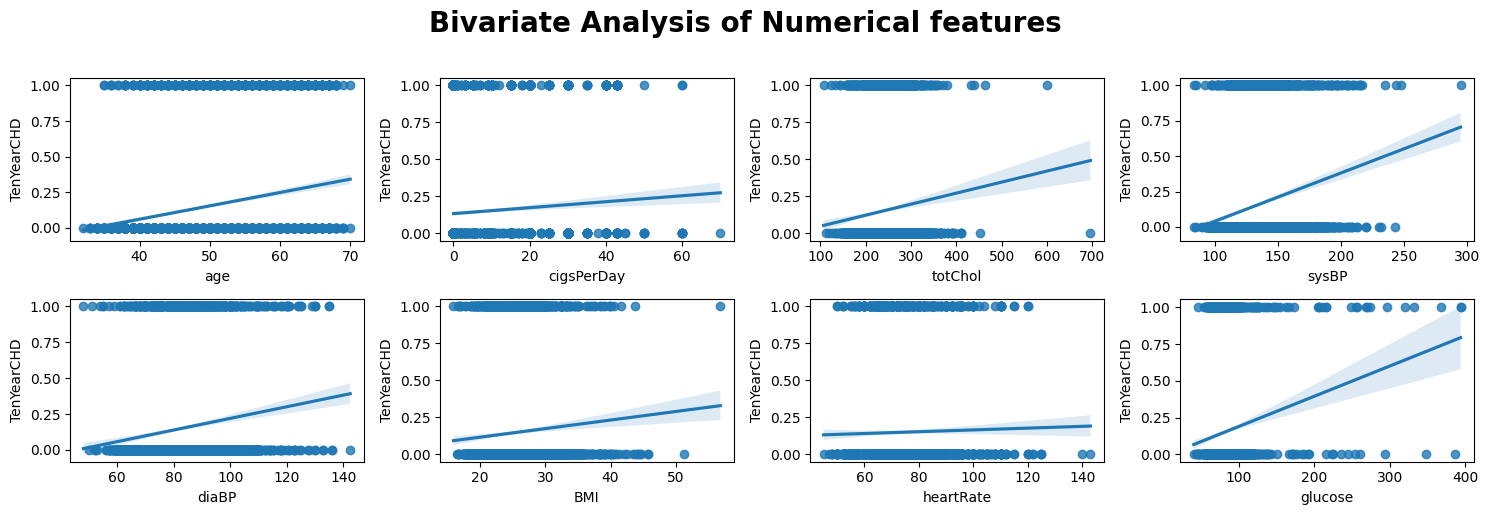

In [46]:
# Checking Linearity of all numerical features with our target variable

# figsize
plt.figure(figsize=(15,5))
# title
plt.suptitle('Bivariate Analysis of Numerical features', fontsize=20, fontweight='bold', y=1.02)

for i,col in enumerate(numeric_features[1:]):
  plt.subplot(2, 4, i+1)                     # subplots of 2 rows and 4 columns

  # regression plots
  sns.regplot(x=risk_df[col], y=risk_df['TenYearCHD'])
  # x-axis lable
  plt.xlabel(col)
  plt.tight_layout()